<a href="https://colab.research.google.com/github/LukaszRoszyk/lecture1/blob/main/pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_31258/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.
First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [4]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [5]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

oblicz VIF (usuń jeśli jest kolumna z wartością więcej niż 10)

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df_input):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = df_input.columns
    vif_df["VIF"] = [variance_inflation_factor(df_input.values, i) for i in range(len(df_input.columns))]
    return vif_df

# Obliczenie początkowego VIF
vif_results = calculate_vif(X)
print("VIF przed usunięciem:")
print(vif_results.sort_values(by='VIF', ascending=False))

# Identyfikacja kolumn do usunięcia (VIF > 10)
high_vif_cols = vif_results[vif_results['VIF'] > 10]['Feature'].tolist()

if high_vif_cols:
    print(f"\nUsuwam kolumny z VIF > 10: {high_vif_cols}")
    X_reduced = X.drop(columns=high_vif_cols)
    X_train = X_train.drop(columns=high_vif_cols)
    X_test = X_test.drop(columns=high_vif_cols)

    # Ponowne sprawdzenie VIF
    print("\nNowe wartości VIF:")
    print(calculate_vif(X_reduced).sort_values(by='VIF', ascending=False))
else:
    print("\nBrak kolumn o współczynniku VIF wyższym niż 10.")

VIF przed usunięciem:
               Feature        VIF
0                  Age  15.191310
4  Years of Experience   9.479247
3            Job Title   4.865563
2      Education Level   2.403316
1               Gender   2.059767

Usuwam kolumny z VIF > 10: ['Age']

Nowe wartości VIF:
               Feature       VIF
3  Years of Experience  4.147387
2            Job Title  2.798903
1      Education Level  2.379329
0               Gender  1.819647


Spróbuj poprawić wynik używając regresji LASSO

regresja liniowa LASSO

In [9]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Definicja parametrów do przeszukania
params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# Inicjalizacja i dopasowanie modelu Lasso z walidacją krzyżową
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, params, scoring='neg_mean_absolute_error', cv=5)
lasso_cv.fit(X_train, y_train)

# Najlepszy model
best_lasso = lasso_cv.best_estimator_
print(f"Najlepsze alpha: {lasso_cv.best_params_['alpha']}")

# Ewaluacja
y_pred_lasso = best_lasso.predict(X_test)
print(f"MAE (Lasso): {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"R^2 (Lasso): {r2_score(y_test, y_pred_lasso):.2f}")
print(f"Współczynniki: {dict(zip(X.columns, best_lasso.coef_))}")

Najlepsze alpha: 100
MAE (Lasso): 11022.26
R^2 (Lasso): 0.89
Współczynniki: {'Age': np.float64(5526.659351775173), 'Gender': np.float64(13914.726304957145), 'Education Level': np.float64(45.91214557277288), 'Job Title': np.float64(5861.317599164795)}


regresja wielomianowa stopnia 2 i 3

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

results = []

for degree in [2, 3]:
    # Tworzenie modelu: Transformacja wielomianowa + Regresja liniowa
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    poly_model.fit(X_train, y_train)

    # Predykcja i ewaluacja
    y_pred_poly = poly_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    results.append({'Degree': degree, 'MAE': mae, 'R2': r2})
    print(f"Stopień {degree}: MAE = {mae:.2f}, R^2 = {r2:.2f}")

# Porównanie wyników
poly_results_df = pd.DataFrame(results)
print("\nPodsumowanie regresji wielomianowej:")
print(poly_results_df)

Stopień 2: MAE = 10244.77, R^2 = 0.89
Stopień 3: MAE = 10987.82, R^2 = 0.85

Podsumowanie regresji wielomianowej:
   Degree           MAE        R2
0       2  10244.772707  0.894786
1       3  10987.824458  0.850915


regresja  k-NN

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Tworzenie potoku: Skalowanie + k-NN
# Domyślnie n_neighbors=5
knn_regressor = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))
knn_regressor.fit(X_train, y_train)

# Predykcja i ewaluacja
y_pred_knn = knn_regressor.predict(X_test)
print(f"MAE (k-NN): {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"R^2 (k-NN): {r2_score(y_test, y_pred_knn):.2f}")

MAE (k-NN): 11702.23
R^2 (k-NN): 0.88


porównaj wyniki błędów na zbiorze testowym

In [12]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# Przygotowanie listy wyników
comparison_data = [
    {"Model": "Linear Regression", "MAE": mean_absolute_error(y_test, y_pred), "R2": r2_score(y_test, y_pred)},
    {"Model": "Lasso (Best Alpha)", "MAE": mean_absolute_error(y_test, y_pred_lasso), "R2": r2_score(y_test, y_pred_lasso)},
    {"Model": "Polynomial Degree 2", "MAE": poly_results_df.loc[0, 'MAE'], "R2": poly_results_df.loc[0, 'R2']},
    {"Model": "Polynomial Degree 3", "MAE": poly_results_df.loc[1, 'MAE'], "R2": poly_results_df.loc[1, 'R2']},
    {"Model": "k-NN Regressor", "MAE": mean_absolute_error(y_test, y_pred_knn), "R2": r2_score(y_test, y_pred_knn)}
]

# Utworzenie DataFrame do wyświetlenia
summary_df = pd.DataFrame(comparison_data)
print("Porównanie wyników modeli na zbiorze testowym:")
print(summary_df.sort_values(by='MAE'))

Porównanie wyników modeli na zbiorze testowym:
                 Model           MAE        R2
2  Polynomial Degree 2  10244.772707  0.894786
3  Polynomial Degree 3  10987.824458  0.850915
1   Lasso (Best Alpha)  11022.264199  0.893717
0    Linear Regression  11377.183127  0.888213
4       k-NN Regressor  11702.232143  0.876317


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [13]:
# Tworzenie nowej zmiennej: kwadrat lat doświadczenia
X_train_poly = X_train.copy()
X_test_poly = X_test.copy()

X_train_poly['Years_Exp_2'] = X_train_poly['Years of Experience'] ** 2
X_test_poly['Years_Exp_2'] = X_test_poly['Years of Experience'] ** 2

# Budowa ponownej regresji
reg_poly_feat = LinearRegression().fit(X_train_poly, y_train)
y_pred_poly_feat = reg_poly_feat.predict(X_test_poly)

# Ewaluacja
mae_poly_feat = mean_absolute_error(y_test, y_pred_poly_feat)
r2_poly_feat = r2_score(y_test, y_pred_poly_feat)

print(f"Wyniki po dodaniu 'Years of Experience^2':")
print(f"MAE: {mae_poly_feat:.2f}")
print(f"R^2: {r2_poly_feat:.2f}")

Wyniki po dodaniu 'Years of Experience^2':
MAE: 10749.87
R^2: 0.89


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

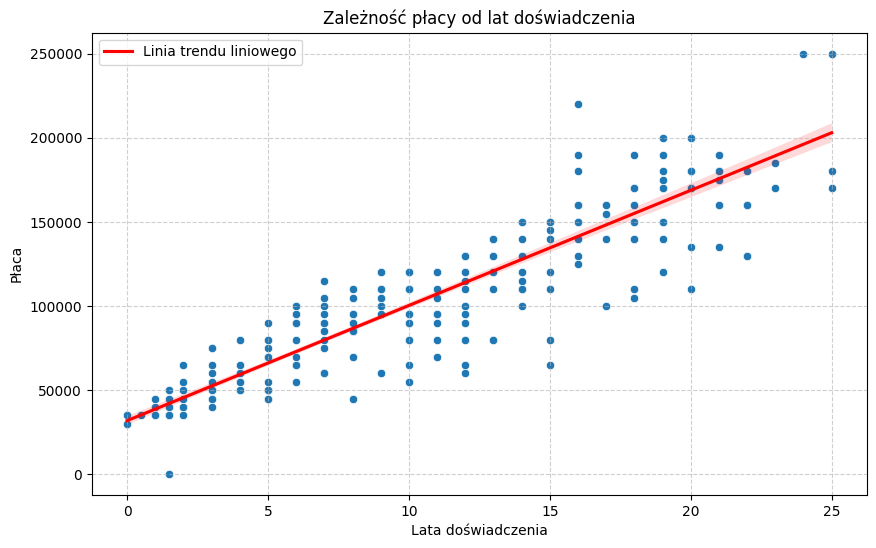

Wizualizacja sugeruje, czy trend jest liniowy. Jeśli punkty układają się w krzywą, regresja wielomianowa jest uzasadniona.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Years of Experience', y='Salary')
sns.regplot(data=df, x='Years of Experience', y='Salary', scatter=False, color='red', label='Linia trendu liniowego')

plt.title('Zależność płacy od lat doświadczenia')
plt.xlabel('Lata doświadczenia')
plt.ylabel('Płaca')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Wizualizacja sugeruje, czy trend jest liniowy. Jeśli punkty układają się w krzywą, regresja wielomianowa jest uzasadniona.")